In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [4]:
len(words)

32033

In [5]:
# build the vocabulary of characters and to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

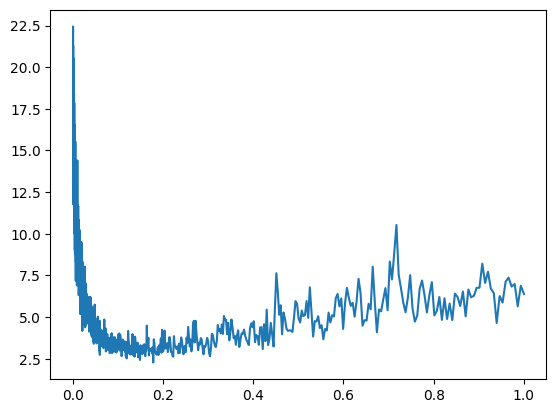

In [195]:
plt.plot(lri, lossi)

In [218]:
# build the dataset

def build_dataset(words):
  block_size = 3 # context length: how many characters do we take to predict the next one?
  X, Y = [], []

  for w in words:
    # print(w)
    context = [0] * block_size # context contains stoi[characters] -> 0..26 where 0 = '.'
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      # print(''.join(itos[i] for i in context), '----->', itos[ix])
      context = context[1:] + [ix] # crop and append



  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y


import random
random.seed(43)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))


Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182460, 3]) torch.Size([182460])
torch.Size([22811, 3]) torch.Size([22811])
torch.Size([22875, 3]) torch.Size([22875])


In [296]:
# initialize network
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [297]:
sum(p.nelement() for p in parameters)

11897

In [298]:
for p in parameters:
  p.requires_grad=True

In [299]:
lossi = []
stepi = []

In [300]:
for i in range(200000):

  # minibatch construct
  ix = torch.randint(1, Xtr.shape[0], (32, ))

  # forward pass
  emb = C[Xtr[ix]] # (32, 2, 6)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  lossi.append(loss.log10().item())
  stepi.append(i)

print(loss.item())

1.874968409538269


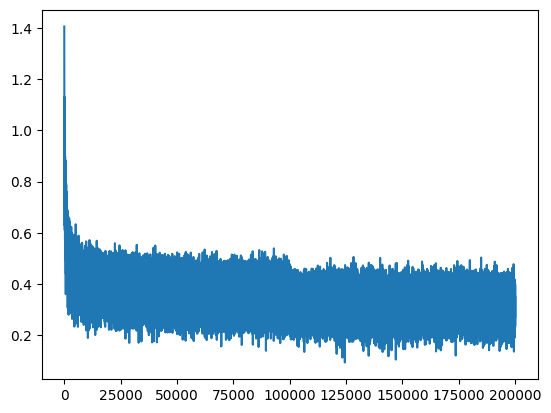

In [301]:
plt.plot(stepi, lossi)

In [302]:
# train loss
emb = C[Xtr] # (32, 2, 6)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1171, grad_fn=<NllLossBackward0>)

In [303]:
# dev loss
emb = C[Xdev] # (32, 2, 6)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1949, grad_fn=<NllLossBackward0>)

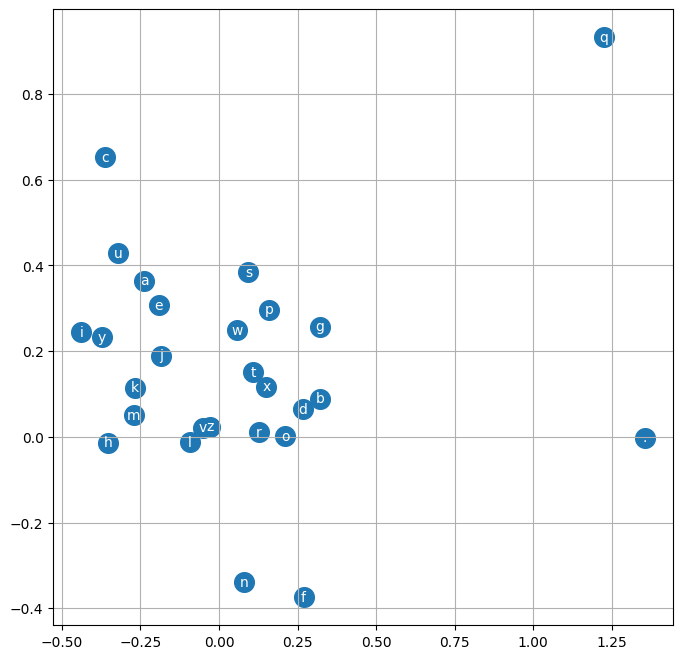

In [287]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
  plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

In [319]:
# sampling

g = torch.Generator().manual_seed(2147483647+5)

for _ in range(20):

  out = []
  context = [0] * 3 # initialize with all ...
  while True:
    emb = C[torch.tensor([context])] # (1, block_size, d)
    h = torch.tanh(emb.view(1, -1) @ W1 + b1)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1, generator=g).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break

  print(''.join(itos[i] for i in out))

jazayla.
ahronnetir.
has.
yoctar.
dereylai.
jovaria.
berkes.
biaureontes.
enrenuce.
lucila.
waina.
ajarilinn.
bleigh.
falle.
fohemita.
vin.
kel.
tahan.
ceclylon.
esry.
